# Urban Heat Islands & Climate Justice
### Sciences Po – Technology for Global Challenges, 2026

---

**Learning objectives**

By the end of this session you will be able to:
1. Load and visualise a long-run climate time series and quantify a warming trend.
2. Define *heatwaves* using a threshold-based rule and track their frequency and intensity over time.
3. Map *Local Climate Zones* (LCZ) as a proxy for urban heat exposure.
4. Combine socioeconomic and spatial data to analyse **climate justice** – who is most exposed to heat, and who has least access to care?

---

**Data used**

| Dataset | Source | Spatial scale |
|---------|--------|---------------|
| Daily temperature & precipitation (1970–2024) | Météo-France / SAFRAN | Point (Lyon) |
| Local Climate Zones 2022 | SPOT satellite | ~50 m polygons |
| Population & income grid | INSEE Filosofi 2019 | 200 m cells |
| Healthcare facilities | OpenStreetMap (Overpass) | Points |


## 0 · Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import geopandas as gpd
import seaborn as sns
from shapely.geometry import box
import warnings
warnings.filterwarnings('ignore')

# ── Shared style ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = sns.color_palette("colorblind")
FIG_W, FIG_H = 11, 5


---
## Part 1 – Historical Climate Analysis

We start with daily climate records for the Lyon grid cell from the SAFRAN reanalysis
(1970–2024).  The pre-processed CSV contains four variables:

| Column | Description | Unit |
|--------|-------------|------|
| `time` | Date | – |
| `temperature` | Mean daily temperature | °C |
| `temperature_max` | Maximum daily temperature | °C |
| `precipitation` | Daily precipitation | mm |


In [2]:
path = 'data/climate_lyon_daily.csv'
df_climate = pd.read_csv(path, parse_dates=['time'])
df_climate = df_climate[df_climate['time'].dt.year <= 2024]
df_climate.head()


,time,temperature,temperature_max,precipitation
0,1970-01-01,-2.1,-1.6,0.0
1,1970-01-02,-1.9,-0.4,0.0
2,1970-01-03,-3.6,-0.1,0.0
3,1970-01-04,2.3,10.0,3.7
4,1970-01-05,4.5,9.0,2.7


---
> **❓ Question 1 · Explore the dataset**
>
> - When does the dataset start? What is its temporal resolution?
> - Which variables are available?
> - How many observations does it contain?


In [3]:
# -- YOUR CODE HERE --
# Explore the dataset: shape, dtypes, date range...
print(df_climate.shape)
print(df_climate.dtypes)
print(f"Period: {df_climate['time'].min().date()} -> {df_climate['time'].max().date()}")


(20089, 4)
time               datetime64[ns]
temperature               float64
temperature_max           float64
precipitation             float64
dtype: object
Period: 1970-01-01 -> 2024-12-31


### 1.1 Long-run temperature trend

We resample the daily series to **annual averages** and fit a linear trend to quantify warming.


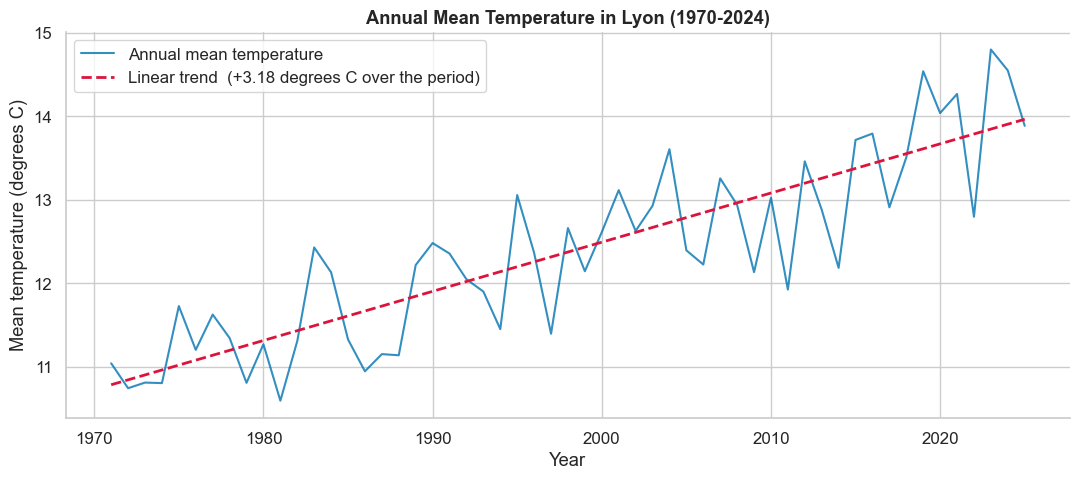

Estimated warming 1970->2024: 3.18 degrees C


In [4]:
# Annual mean temperature
df_annual = df_climate.set_index('time').resample('YE').mean().reset_index()

# Linear trend
X = np.arange(len(df_annual))
slope, intercept = np.polyfit(X, df_annual['temperature'].values, 1)
trend = intercept + slope * X
warming = trend[-1] - trend[0]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.plot(df_annual['time'], df_annual['temperature'],
        color=PALETTE[0], linewidth=1.5, alpha=0.8, label='Annual mean temperature')
ax.plot(df_annual['time'], trend,
        color='crimson', linewidth=2, linestyle='--',
        label=f'Linear trend  (+{warming:.2f} degrees C over the period)')

ax.set_xlabel('Year')
ax.set_ylabel('Mean temperature (degrees C)')
ax.set_title('Annual Mean Temperature in Lyon (1970-2024)', fontweight='bold')
ax.legend(frameon=True)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
sns.despine()
plt.tight_layout()
plt.show()

print(f"Estimated warming 1970->2024: {warming:.2f} degrees C")


---
> **❓ Question 2 · Warming magnitude**
>
> - What is the estimated warming over 1970–2024?
> - Does this figure surprise you?
> - How does it compare to the global average (+1.1 °C since pre-industrial)?


### 1.2 Heatwaves

**Definition used here:** >= 3 consecutive days with `temperature_max` > 30 °C.

The helper function below returns a table of individual heatwave events.


In [5]:
def get_heatwave_events(df, temp_col='temperature', time_col='time',
                        q_pic=0.99, q_start=0.95, q_interrupt=0.90):
    """
    Quantile-based heatwave detection:
    - Trigger: temp > Spic (q99)
    - Event start/back-extension: contiguous days with temp > Sstart (q95)
    - Event ends when temp drops below Sinterup (q90)
    - Intensity = sum((temp - Sstart) / (Spic - Sstart)) over event days
                  (only positive contributions are counted)
    """
    d = df[[time_col, temp_col]].copy()
    d[time_col] = pd.to_datetime(d[time_col])
    d = d.sort_values(time_col).reset_index(drop=True)

    Spic = d[temp_col].quantile(q_pic)
    Sstart = d[temp_col].quantile(q_start)
    Sinterup = d[temp_col].quantile(q_interrupt)

    temps = d[temp_col].to_numpy(float)
    dates = d[time_col].to_numpy()
    n = len(d)
    denom = Spic - Sstart if Spic != Sstart else np.nan

    events = []
    i = 0
    while i < n:
        if temps[i] > Spic:
            # Extend backward using Sstart
            s = i
            while s > 0 and temps[s - 1] > Sstart:
                s -= 1

            # Extend forward until interruption threshold is crossed
            e = i
            while e + 1 < n and temps[e + 1] >= Sinterup:
                e += 1

            seg = temps[s:e + 1]
            if np.isnan(denom) or denom == 0:
                intensity = np.nan
            else:
                intensity = np.sum(np.maximum(seg - Sstart, 0) / denom)

            events.append({
                'start_date': pd.Timestamp(dates[s]),
                'end_date': pd.Timestamp(dates[e]),
                'duration_days': e - s + 1,
                'max_temp': float(np.max(seg)),
                'intensity': float(intensity)
            })

            i = e + 1  # skip to end of current event
        else:
            i += 1

    hw = pd.DataFrame(events)
    if not hw.empty:
        hw['year'] = hw['start_date'].dt.year

    return hw, {'Spic': Spic, 'Sstart': Sstart, 'Sinterup': Sinterup}


heatwaves, thresholds = get_heatwave_events(df_climate, temp_col='temperature')

print(
    f"Thresholds -> Spic (q99): {thresholds['Spic']:.2f}°C | "
    f"Sstart (q95): {thresholds['Sstart']:.2f}°C | "
    f"Sinterup (q90): {thresholds['Sinterup']:.2f}°C"
)
print(f"Total heatwave events detected: {len(heatwaves)}")
heatwaves.sort_values('duration_days', ascending=False).head(10)


Thresholds -> Spic (q99): 27.60°C | Sstart (q95): 24.40°C | Sinterup (q90): 22.40°C
Total heatwave events detected: 58


,start_date,end_date,duration_days,max_temp,intensity,year
54,2022-07-12,2022-08-13,33,31.7,27.25000,2022
19,2003-06-07,2003-06-30,24,29.3,15.43750,2003
57,2024-07-26,2024-08-17,23,30.2,14.18750,2024
47,2019-06-24,2019-07-14,21,30.7,15.46875,2019
28,2010-06-27,2010-07-16,20,28.5,8.96875,2010
26,2006-07-10,2006-07-27,18,29.5,17.00000,2006
21,2003-08-02,2003-08-19,18,31.5,23.62500,2003
2,1983-07-16,1983-08-01,17,31.7,20.37500,1983
46,2018-07-23,2018-08-08,17,31.6,20.15625,2018
51,2020-08-06,2020-08-22,17,29.3,9.43750,2020


---
> **❓ Question 3 · Heatwave frequency over time**
>
> Plot the **number of heatwave events per year** as a bar chart with a linear trend line.
>
> - In which decade do the first events appear?
> - Is there a clear trend?


In [6]:
# -- YOUR CODE HERE --
# Hint: use heatwaves.groupby('year').size()
# Then reindex to fill years with 0 heatwaves
# Plot with plt.bar and overlay a trend line


---
> **❓ Question 4 · Longest heatwave**
>
> Which event had the longest duration? In which year did it occur?


In [7]:
heatwaves.sort_values('duration_days', ascending=False).head(5)


,start_date,end_date,duration_days,max_temp,intensity,year
54,2022-07-12,2022-08-13,33,31.7,27.25000,2022
19,2003-06-07,2003-06-30,24,29.3,15.43750,2003
57,2024-07-26,2024-08-17,23,30.2,14.18750,2024
47,2019-06-24,2019-07-14,21,30.7,15.46875,2019
28,2010-06-27,2010-07-16,20,28.5,8.96875,2010


### 1.3 Heatwave days and intensity per year

Beyond frequency, two other metrics matter:
* **Heatwave days per year** – total days spent in heatwave conditions ($T > S_\text{start}$).
* **Annual intensity** – sum of per-event intensity indices as defined in 1.2, i.e. the cumulative normalised temperature excess $\sum \max(T - S_\text{start}, 0)\,/\,(S_\text{pic} - S_\text{start})$ aggregated over all events in the year. A higher value indicates years with more severe or prolonged heat stress.

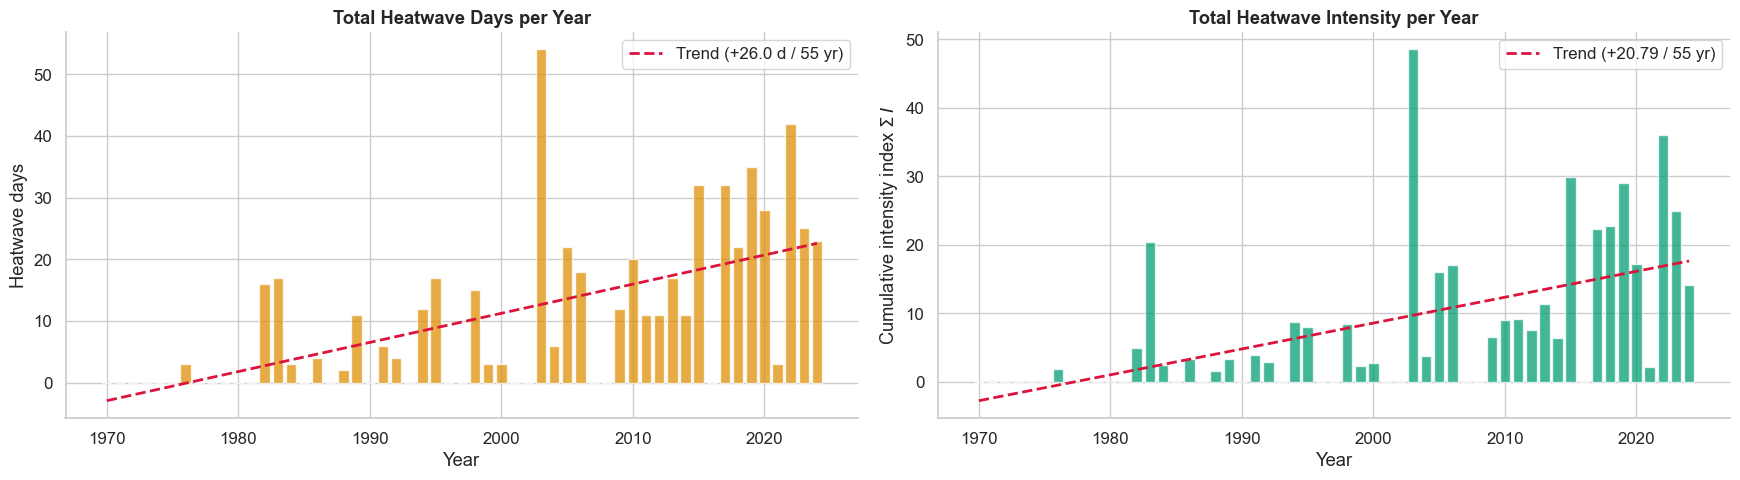

In [8]:
# ── Days per year ─────────────────────────────────────────────────────────────
all_years = pd.Series(0, index=df_annual['time'].dt.year.values, dtype=float)
days_per_year = heatwaves.groupby('year')['duration_days'].sum()
days_per_year = all_years.add(days_per_year, fill_value=0)

# ── Intensity per year: sum of per-event intensity indices (from 1.2) ─────────
intensity_per_year = heatwaves.groupby('year')['intensity'].sum()
intensity_per_year = intensity_per_year.reindex(all_years.index, fill_value=0)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(FIG_W * 1.6, FIG_H))

# Left: days
ax = axes[0]
Xd = np.arange(len(days_per_year))
sl, ic = np.polyfit(Xd, days_per_year.values, 1)
ax.bar(days_per_year.index, days_per_year.values,
       color=PALETTE[1], alpha=0.75)
ax.plot(days_per_year.index, ic + sl * Xd,
        color='crimson', linewidth=2, linestyle='--',
        label=f'Trend (+{sl*55:.1f} d / 55 yr)')
ax.set_xlabel('Year')
ax.set_ylabel('Heatwave days')
ax.set_title('Total Heatwave Days per Year', fontweight='bold')
ax.legend(frameon=True)

# Right: intensity
ax = axes[1]
Xi = np.arange(len(intensity_per_year))
sl2, ic2 = np.polyfit(Xi, intensity_per_year.values, 1)
ax.bar(intensity_per_year.index, intensity_per_year.values,
       color=PALETTE[2], alpha=0.75)
ax.plot(intensity_per_year.index, ic2 + sl2 * Xi,
        color='crimson', linewidth=2, linestyle='--',
        label=f'Trend (+{sl2*55:.2f} / 55 yr)')
ax.set_xlabel('Year')
ax.set_ylabel(r'Cumulative intensity index $\Sigma\,I$')
ax.set_title('Total Heatwave Intensity per Year', fontweight='bold')
ax.legend(frameon=True)

sns.despine()
plt.tight_layout()
plt.show()

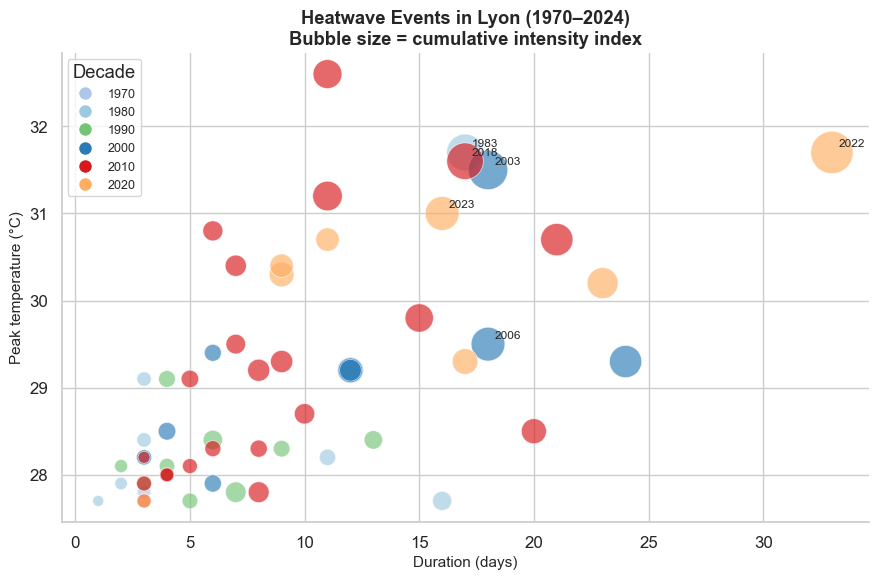

In [9]:
# ── Bubble chart: duration (x), max_temp (y), bubble size = intensity ─────────
from matplotlib.lines import Line2D

# Scale bubble area proportional to intensity
sz = (heatwaves['intensity'] / heatwaves['intensity'].max()) * 900 + 30

# Colour by decade
decade = (heatwaves['year'] // 10) * 10
decade_colors = {1970: '#aec7e8', 1980: '#9ecae1', 1990: '#74c476',
                 2000: '#2c7bb6', 2010: '#d7191c', 2020: '#fdae61'}
colors = decade.map(decade_colors)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(heatwaves['duration_days'], heatwaves['max_temp'],
           s=sz, c=colors, alpha=0.65, edgecolors='white', linewidths=0.6)

# Label the 6 most intense events
for _, row in heatwaves.nlargest(6, 'intensity').iterrows():
    ax.annotate(str(int(row['year'])),
                xy=(row['duration_days'], row['max_temp']),
                xytext=(5, 4), textcoords='offset points', fontsize=8.5)

ax.set_xlabel('Duration (days)', fontsize=11)
ax.set_ylabel('Peak temperature (°C)', fontsize=11)
ax.set_title('Heatwave Events in Lyon (1970–2024)\nBubble size = cumulative intensity index',
             fontweight='bold')

# Decade legend
handles = [Line2D([0], [0], marker='o', color='w',
                  markerfacecolor=c, markersize=10, label=str(d))
           for d, c in decade_colors.items() if d in decade.values]
ax.legend(handles=handles, title='Decade', frameon=True, loc='upper left', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

---
> **❓ Question 5 · Analysis of the dependence between duration, peak and intensity**
>
> What are your thoughts on the links between duration, peak and intensity ? Where does that come from?

---
## Part 2 – Spatial Exposure: Local Climate Zones

**Local Climate Zones (LCZ)** classify urban and rural landscapes into 17 types based on
surface cover, building morphology, and human activity.  In the context of urban heat:

| LCZ class | Description | Heat retention |
|-----------|-------------|----------------|
| 1–3 | Compact high/mid/low-rise | High |
| 4–6 | Open high/mid/low-rise | Medium-high |
| 8–9 | Large low-rise, sparsely built | Medium |
| 10 | Heavy industry | Medium |
| 11–15 | Natural: dense/scattered trees, bush… | Low |
| 17 | Water | Cooling |

We load a pre-processed GeoPackage that combines LCZ polygons with:
- `ind` – total population (200 m grid)
- `ind_80p` – population aged 80+
- `ind_snv` – median standard of living (euros/year)
- `ver` – vegetation cover (%)
- `ror` – impervious surface cover (%)
- `dist_to_hospital` – distance to nearest hospital/clinic (m)


In [11]:
import xarray as xr
path = 'ds_filo_lcz_aligned.nc'
ds = xr.open_dataset(path)


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\colin\\Documents\\Thèse\\Cours\\2026-Sciences Po\\TD1\\ds_filo_lcz_aligned.nc'

### 2.1 Maps

In [ ]:
import folium
from branca.colormap import LinearColormap
from IPython.display import display as ipy_display

# ── WUDAPT standard LCZ colors ────────────────────────────────────────────────
LCZ_COLORS = {
    1: '#910613', 2: '#D9081C', 3: '#FF0A22',
    4: '#C54F1E', 5: '#FF6628', 6: '#FF985E',
    7: '#FDED22', 8: '#BBBBBB', 9: '#FFCCAA', 10: '#555555',
    11: '#006A18', 12: '#00A926', 13: '#628432',
    14: '#B5DA7F', 15: '#000000', 16: '#FCF7B0', 17: '#656BFA',
}

# Pre-project + simplify for folium (needs EPSG:4326)
lcz_folium = lcz.to_crs('EPSG:4326').copy()
lcz_folium['geometry'] = lcz_folium.geometry.simplify(tolerance=0.0003)


def make_lcz_map(gdf, lcz_code: int, lcz_label: str, zoom: int = 12) -> folium.Map:
    """
    Interactive folium map highlighting a single LCZ type.

    Parameters
    ----------
    gdf       : GeoDataFrame in EPSG:4326
    lcz_code  : int  – LCZ type code (1–17)
    lcz_label : str  – Human-readable label (e.g. 'Compact high-rise')
    zoom      : int  – Initial zoom level

    Returns
    -------
    folium.Map  (displays inline in Jupyter when returned or via ipy_display())
    """
    subset = gdf[gdf['lcz_int'] == lcz_code]
    if subset.empty:
        raise ValueError(f"No polygons found for LCZ code {lcz_code}")

    color = LCZ_COLORS.get(lcz_code, '#888888')
    b = subset.total_bounds          # [minx, miny, maxx, maxy]
    center = [(b[1] + b[3]) / 2, (b[0] + b[2]) / 2]

    m = folium.Map(location=center, zoom_start=zoom, tiles='CartoDB positron')

    tt_cols, tt_aliases = ['lcz_int'], ['LCZ code']
    for col, alias in [('ver', 'Vegetation (%)'), ('ror', 'Impervious (%)'),
                       ('ind_snv', 'Median income (€/yr)')]:
        if col in subset.columns and subset[col].notna().any():
            tt_cols.append(col)
            tt_aliases.append(alias)

    folium.GeoJson(
        subset[['geometry'] + tt_cols].__geo_interface__,
        name=lcz_label,
        style_function=lambda feat, c=color: {
            'fillColor': c, 'color': 'white', 'weight': 0.3, 'fillOpacity': 0.7,
        },
        tooltip=folium.GeoJsonTooltip(fields=tt_cols, aliases=tt_aliases)
    ).add_to(m)

    folium.LayerControl().add_to(m)
    m.get_root().html.add_child(folium.Element(
        f'<h4 style="position:fixed;top:10px;left:60px;z-index:1000;background:white;'
        f'padding:5px 10px;border-radius:4px;box-shadow:2px 2px 4px rgba(0,0,0,.3)">'
        f'LCZ {lcz_code} – {lcz_label}</h4>'
    ))
    return m


def _make_choropleth(gdf, column, label, title,
                     colors=None, vmin=None, vmax=None, zoom=12):
    """Folium choropleth for a continuous variable across all LCZ polygons."""
    g = gdf[gdf[column].notna()]
    b = g.total_bounds
    center = [(b[1] + b[3]) / 2, (b[0] + b[2]) / 2]
    lo = float(vmin if vmin is not None else g[column].quantile(0.05))
    hi = float(vmax if vmax is not None else g[column].quantile(0.95))
    if colors is None:
        colors = ['#ffffb2', '#fecc5c', '#fd8d3c', '#f03b20', '#bd0026']

    cm = LinearColormap(colors, vmin=lo, vmax=hi, caption=label)
    m = folium.Map(location=center, zoom_start=zoom, tiles='CartoDB positron')
    cm.add_to(m)

    def style_fn(feat):
        v = feat['properties'].get(column)
        return {'fillColor': cm(v) if v is not None else '#cccccc',
                'color': 'none', 'weight': 0, 'fillOpacity': 0.7}

    folium.GeoJson(
        g[['geometry', column]].__geo_interface__,
        style_function=style_fn,
        tooltip=folium.GeoJsonTooltip(fields=[column], aliases=[label])
    ).add_to(m)
    m.get_root().html.add_child(folium.Element(
        f'<h4 style="position:fixed;top:10px;left:60px;z-index:1000;background:white;'
        f'padding:5px 10px;border-radius:4px;box-shadow:2px 2px 4px rgba(0,0,0,.3)">'
        f'{title}</h4>'
    ))
    return m

In [ ]:
# ── 1. LCZ type map (categorical, WUDAPT colors) ──────────────────────────────
b0 = lcz_folium.total_bounds
center0 = [(b0[1] + b0[3]) / 2, (b0[0] + b0[2]) / 2]
m_lcz = folium.Map(location=center0, zoom_start=12, tiles='CartoDB positron')

folium.GeoJson(
    lcz_folium[['geometry', 'lcz_int']].__geo_interface__,
    name='LCZ types',
    style_function=lambda feat: {
        'fillColor': LCZ_COLORS.get(int(feat['properties']['lcz_int']), '#888'),
        'color': 'none', 'weight': 0, 'fillOpacity': 0.75,
    },
    tooltip=folium.GeoJsonTooltip(fields=['lcz_int'], aliases=['LCZ code'])
).add_to(m_lcz)
m_lcz.get_root().html.add_child(folium.Element(
    '<h4 style="position:fixed;top:10px;left:60px;z-index:1000;background:white;'
    'padding:5px 10px;border-radius:4px;box-shadow:2px 2px 4px rgba(0,0,0,.3)">'
    'Local Climate Zones</h4>'
))
ipy_display(m_lcz)

# ── 2. Vegetation cover ────────────────────────────────────────────────────────
ipy_display(_make_choropleth(
    lcz_folium, 'ver', 'Vegetation cover (%)', 'Vegetation Cover',
    colors=['#f7fcf5', '#c7e9c0', '#74c476', '#238b45', '#00441b'],
    vmin=0, vmax=100
))

# ── 3. Impervious surface ──────────────────────────────────────────────────────
ipy_display(_make_choropleth(
    lcz_folium, 'ror', 'Impervious surface (%)', 'Impervious Surface Cover',
    colors=['#fff5eb', '#fdd0a2', '#fd8d3c', '#d94801', '#7f2704'],
    vmin=0, vmax=100
))

# ── 4. Median income ───────────────────────────────────────────────────────────
ipy_display(_make_choropleth(
    lcz_folium, 'ind_snv', 'Median income (€/yr)', 'Median Standard of Living',
    colors=['#d73027', '#fdae61', '#ffffbf', '#a6d96a', '#1a9641'],
    vmin=12000, vmax=50000
))

---
> **❓ Question 5 · Visual inspection of the maps**
>
> Looking at the four maps:
> 1. Where are the most urbanised (compact) LCZ classes located?
> 2. Is there a visible spatial correlation between vegetation cover and income?
> 3. Which areas combine **high impervious surface** AND **low income**?
>    Why might this be concerning from a climate justice perspective?


---
## Part 3 – Climate Justice Analysis

We now test whether socioeconomic status predicts exposure to heat risk factors.
We divide the study area into **income deciles** (D1 = poorest 10%, D10 = richest 10%)
and compare four indicators across deciles.


In [ ]:
# Work only on polygons with population data and urban LCZ (class < 10)
dt = lcz.dropna(subset=['ind_snv', 'ver', 'ror']).copy()
dt = dt[dt['lcz_int'] < 10]     # exclude natural / rural zones

dt['decile_snv'] = pd.qcut(dt['ind_snv'], 10, labels=False)
print(f"Urban polygons with income data: {len(dt):,}")


Urban polygons with income data: 3,303


### 3.1 Vegetation cover by income decile

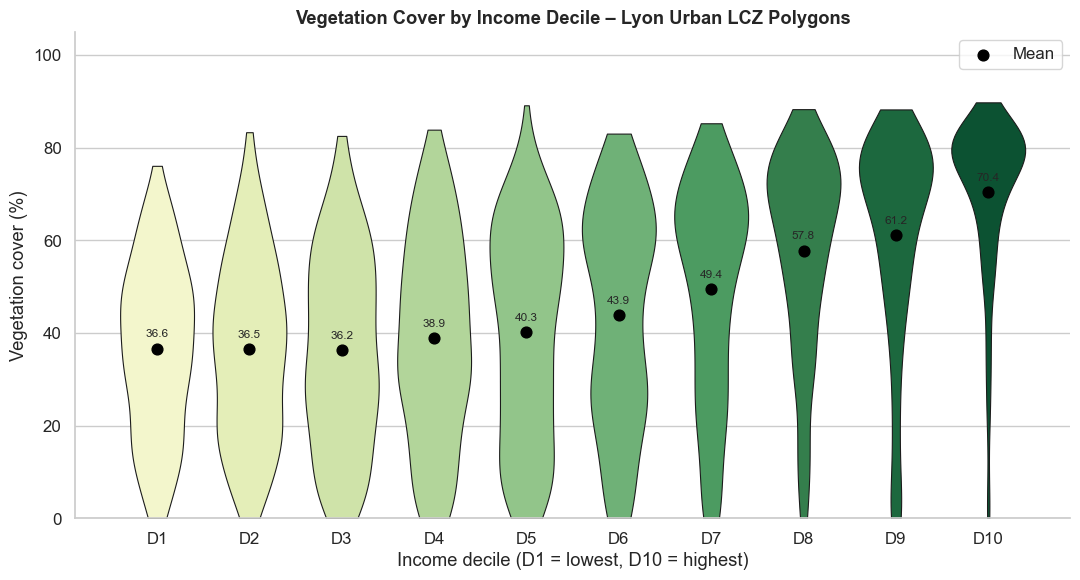

In [ ]:
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 1))

pal_g = sns.color_palette("YlGn", 10)
sns.violinplot(x='decile_snv', y='ver', data=dt,
               order=range(10), palette=pal_g, ax=ax,
               inner=None, cut=0, linewidth=0.8)

means_ver = dt.groupby('decile_snv')['ver'].mean()
ax.scatter(means_ver.index, means_ver.values,
           color='black', s=60, zorder=5, label='Mean')

for i, val in enumerate(means_ver):
    ax.text(i, val + 2.5, f'{val:.1f}', ha='center', fontsize=8.5)

ax.set_xticks(range(10))
ax.set_xticklabels([f'D{i+1}' for i in range(10)])
ax.set_xlabel('Income decile (D1 = lowest, D10 = highest)')
ax.set_ylabel('Vegetation cover (%)')
ax.set_title('Vegetation Cover by Income Decile – Lyon Urban LCZ Polygons',
             fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(frameon=True)
sns.despine()
plt.tight_layout()
plt.show()


---
> **❓ Question 6 · Green inequality**
>
> - Describe the relationship between income and vegetation cover.
> - Is the difference between D1 and D10 large?
> - What policy interventions could reduce this gap?


### 3.2 Impervious surface cover by income decile

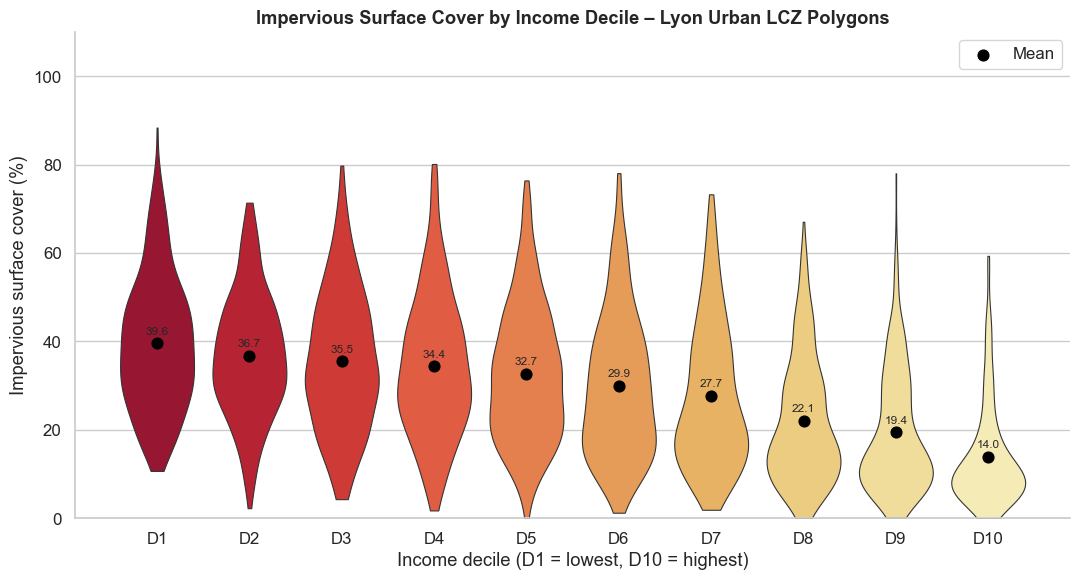

In [ ]:
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 1))

pal_r = sns.color_palette("YlOrRd", 10)[::-1]
sns.violinplot(x='decile_snv', y='ror', data=dt,
               order=range(10), palette=pal_r, ax=ax,
               inner=None, cut=0, linewidth=0.8)

means_ror = dt.groupby('decile_snv')['ror'].mean()
ax.scatter(means_ror.index, means_ror.values,
           color='black', s=60, zorder=5, label='Mean')

for i, val in enumerate(means_ror):
    ax.text(i, val + 2, f'{val:.1f}', ha='center', fontsize=8.5)

ax.set_xticks(range(10))
ax.set_xticklabels([f'D{i+1}' for i in range(10)])
ax.set_xlabel('Income decile (D1 = lowest, D10 = highest)')
ax.set_ylabel('Impervious surface cover (%)')
ax.set_title('Impervious Surface Cover by Income Decile – Lyon Urban LCZ Polygons',
             fontweight='bold')
ax.set_ylim(0, 110)
ax.legend(frameon=True)
sns.despine()
plt.tight_layout()
plt.show()


### 3.3 Distance to nearest hospital/clinic by income decile

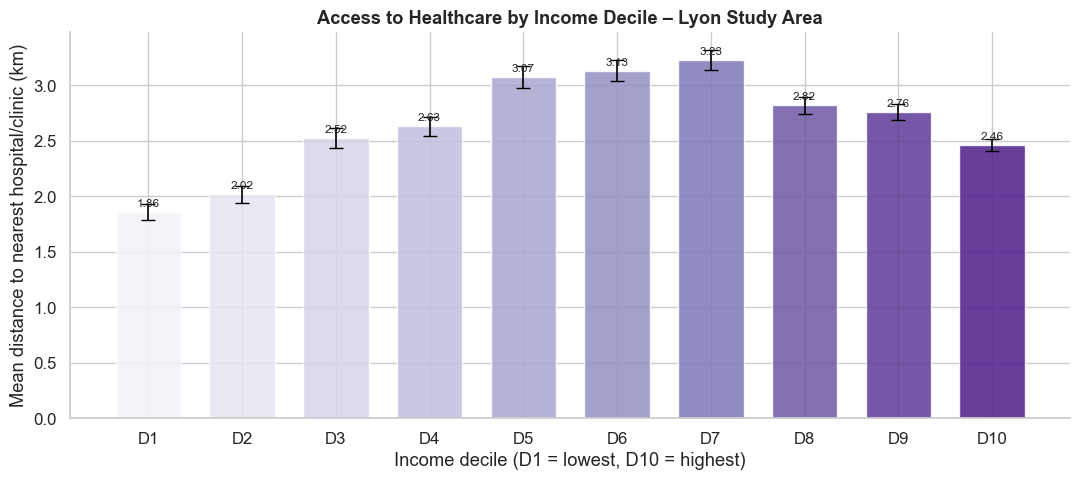

In [ ]:
dt_hosp = lcz.dropna(subset=['ind_snv', 'dist_to_hospital']).copy()
dt_hosp['decile_snv'] = pd.qcut(dt_hosp['ind_snv'], 10, labels=False)

stats_h = dt_hosp.groupby('decile_snv')['dist_to_hospital'].agg(['mean','sem']).sort_index()
stats_h.columns = ['mean', 'sem']

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
pal_p = sns.color_palette("Purples", 10)
ax.bar(stats_h.index, stats_h['mean'] / 1000,
       color=pal_p, alpha=0.85, width=0.7)
ax.errorbar(stats_h.index, stats_h['mean'] / 1000,
            yerr=stats_h['sem'] / 1000,
            fmt='none', ecolor='black', capsize=5, linewidth=1.2)

for i, val in enumerate(stats_h['mean'] / 1000):
    ax.text(i, val + 0.05, f'{val:.2f}', ha='center', fontsize=8.5)

ax.set_xticks(range(10))
ax.set_xticklabels([f'D{i+1}' for i in range(10)])
ax.set_xlabel('Income decile (D1 = lowest, D10 = highest)')
ax.set_ylabel('Mean distance to nearest hospital/clinic (km)')
ax.set_title('Access to Healthcare by Income Decile – Lyon Study Area',
             fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()


---
> **❓ Question 7 · Double burden**
>
> Combining the findings from sections 3.1, 3.2, and 3.3:
>
> 1. Which income group faces the worst *combination* of heat exposure and healthcare access?
> 2. Propose a composite **vulnerability index** that captures this double burden.
>    What variables would you include?
> 3. What additional data would strengthen this analysis?


### 3.4 Synthesis: income vs. vegetation cover

A direct scatter plot at polygon level, coloured by impervious surface.


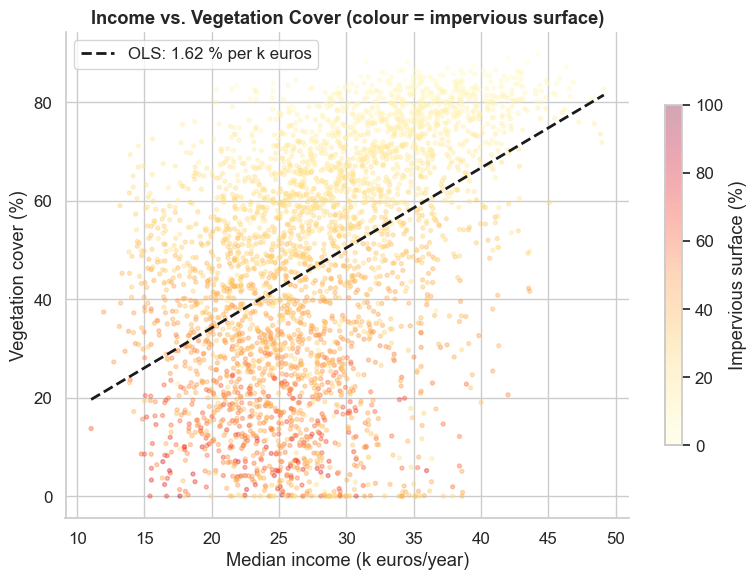

Correlation (income, vegetation): 0.457


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

mask = dt['ind_snv'].notna() & dt['ver'].notna()
sc = ax.scatter(dt.loc[mask, 'ind_snv'] / 1000,
                dt.loc[mask, 'ver'],
                c=dt.loc[mask, 'ror'],
                cmap='YlOrRd', alpha=0.35, s=8, vmin=0, vmax=100)
cbar = fig.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label('Impervious surface (%)')

# OLS line
Xs = dt.loc[mask, 'ind_snv'].values / 1000
Ys = dt.loc[mask, 'ver'].values
sl, ic = np.polyfit(Xs, Ys, 1)
Xline = np.linspace(Xs.min(), Xs.max(), 200)
ax.plot(Xline, ic + sl * Xline, 'k--', linewidth=2,
        label=f'OLS: {sl:.2f} % per k euros')

ax.set_xlabel('Median income (k euros/year)')
ax.set_ylabel('Vegetation cover (%)')
ax.set_title('Income vs. Vegetation Cover (colour = impervious surface)',
             fontweight='bold')
ax.legend(frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Correlation (income, vegetation): {np.corrcoef(Xs, Ys)[0,1]:.3f}")


---
## Conclusion

In this notebook we have shown that Lyon, like most French cities, is experiencing:

1. **Accelerating warming** – roughly +3 °C over 55 years, with more frequent and longer heatwaves.
2. **Unequal exposure** – lower-income urban areas have less vegetation, more impervious surfaces, and greater distances to healthcare.
3. **Climate justice concerns** – the populations least responsible for climate change bear a disproportionate share of its health consequences.

### Further reading


- Lemonsu et al. (2015). *Vulnerability to heat waves: Future heat exposure and human comfort for the agglomeration of Marseille.* Urban Climate.
- Stewart & Oke (2012). *Local Climate Zones for Urban Ecosystem Studies.* BAMS.
- Tuholske et al. (2021). *Global urban population exposure to extreme heat.* PNAS.
